**AVALIAÇÃO N2 - Inteligência Artificial **

Classificadores

Nomes:
- Alyssa Heluany - 061210002
- Guilherme Pereira - 061210033
- Guilherme Suarez - 061210026
- Heloísa Rades - 061210035
- Henrique Aímola - 061210030

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a AVALIÇÃO N2 DO 1º BIMESTRE. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercícico id=40922

1. Carregar os dataset do exercício:

In [3]:
# Tratamento dos dados
import numpy as np
import pandas as pd
from collections import Counter

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Métricas de avaliação
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report
# removed plot_roc_curve as it is deprecated
# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

#Check scikit-learn version
import sklearn
print(sklearn.__version__) # make sure the version is 0.23 or higher

#If the version is lower than 0.23, update scikit-learn
!pip install -U scikit-learn

1.7.2


In [4]:
# Vamos carregar dados publicos
dados = fetch_openml(data_id=40922)
df = pd.DataFrame(dados.data,columns=dados.feature_names)

2. Fazer a análise exploratória dos dados

(Espera-se no minimo que seja verificado os tipos de dados envolvidos e suas médias, desvios padrões e distribuição dos dados - função describe())

In [5]:
df.head()

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-29.2960
1,0.6722,-11.2330,-0.2344,-0.1757,0.0208,0.1269
2,0.4399,-14.8170,0.0722,-0.9105,0.1063,-24.3670
3,0.3031,-0.8125,0.0888,0.1199,-0.4099,-29.3360
4,0.4814,-0.9312,0.0359,0.0527,0.4379,24.9220


In [6]:
df.describe()

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,-0.735403,-3.425864,-1.585894,0.005690,0.285645,0.281254
std,9.419857,5.633842,4.631486,11.779596,11.209552,18.821379
min,-53.505000,-32.990000,-37.538000,-44.306000,-74.647000,-94.800000
25%,-0.381800,-10.335000,-0.376000,-0.920700,-0.644825,-13.451250
50%,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,0.355500,-0.241775,-0.085900,0.888800,0.733700,13.982000
max,56.033000,26.680000,16.403000,48.742000,84.980000,112.662000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   acceleration_x  88588 non-null  float64
 1   acceleration_y  88588 non-null  float64
 2   acceleration_z  88588 non-null  float64
 3   gyro_x          88588 non-null  float64
 4   gyro_y          88588 non-null  float64
 5   gyro_z          88588 non-null  float64
dtypes: float64(6)
memory usage: 4.1 MB


In [8]:
# Compreender o que deve ser classificado
dados.target

,activity
0,0
1,0
2,0
3,0
4,0
...,...
88583,0
88584,0
88585,0
88586,0


array([[<Axes: title={'center': 'acceleration_x'}>,
        <Axes: title={'center': 'acceleration_y'}>],
       [<Axes: title={'center': 'acceleration_z'}>,
        <Axes: title={'center': 'gyro_x'}>],
       [<Axes: title={'center': 'gyro_y'}>,
        <Axes: title={'center': 'gyro_z'}>]], dtype=object)

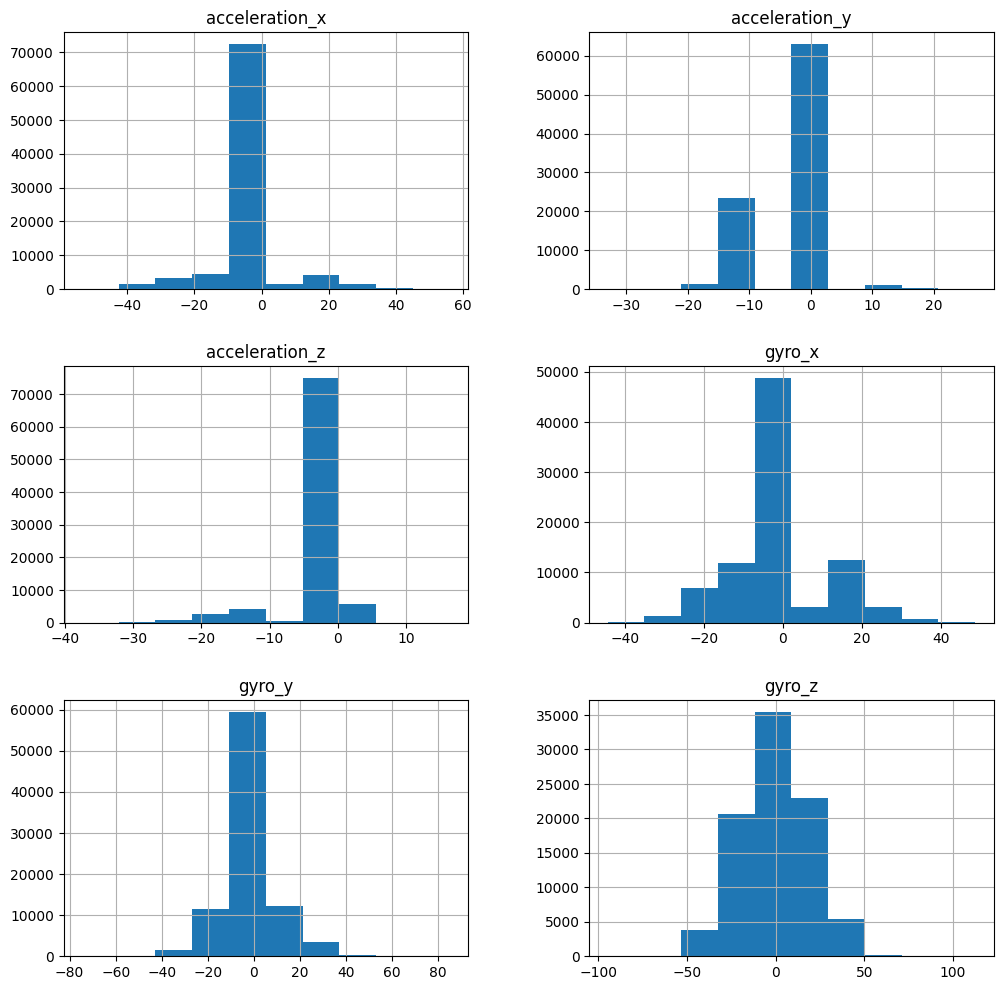

In [9]:
df.hist(figsize=(12,12))

OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

Resposta:  
Os dados utilizados no dataset são provenientes dos eixos x,y e z de acelerômetro e giroscópio de celulares e o target é avaliar se a pessoa está correndo ou andando.  

De acordo com a explicação do dataset no site da OpenML, quando o target é 0, significa que está andando, e quando é 1, significa que está correndo.

3. Dividir os dados em conjunto de treinamento e treinar os modelos

In [10]:
# Verificando a distribuição de classes
Counter(dados.target)

Counter({'0': 44223, '1': 44365})

In [11]:
# Dividindo os dados no conjunto de teste e treinamento
x_train, x_test, y_train, y_test = train_test_split(dados.data, dados.target, test_size=0.3, random_state=42)



# Fazendo a regressao logistica
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

# Fazendo as predições
y_pred_log = log_reg.predict(x_test)

In [12]:
!pip install --upgrade scikit-learn

Prompt para célula abaixo:
Com base no conjunto de dados e nas divisões de teste e treinamento que foram feitos na célula anterior, treine o modelo a partir de uma árvore de decisão para classificação

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Fazendo a arvore de decisão
tree_clf = DecisionTreeClassifier(random_state=31)
tree_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_tree = tree_clf.predict(x_test_scaled)

NameError: name 'x_train_scaled' is not defined

Prompt: Treine o modelo a partir do knn com base nos dados e divisões feitos no notebook

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Fazendo o KNN
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_knn = knn_clf.predict(x_test_scaled)

prompt: Treine o modelo utilizando o svm para classificação com base nos dados e conjuntos que foram criados no notebook

In [ ]:
from sklearn.svm import SVC

# Fazendo o SVM
svm_clf = SVC(random_state=31)
svm_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_svm = svm_clf.predict(x_test_scaled)

In [ ]:
# Comparando usando o DataFrame
pd.DataFrame({'pred_log': y_pred_log, "pred_tree": y_pred_tree, "pred_knn": y_pred_knn,"pred_svm": y_pred_svm,'resp': y_test})

In [ ]:
# Falta verificar overfit

4. Metricas de desempenho

[Precisão, Revocação, Acurácia e F1-Score]

In [ ]:
resultados = [y_pred_log, y_pred_tree, y_pred_knn, y_pred_svm]
nomes = ["Regressão Logística", "Árvore de Decisão", "KNN", "SVM"]
matrizes_confusao = []


for i, pred in enumerate(resultados):
  cm = confusion_matrix(y_test, pred)
  matrizes_confusao.append(cm)
  dips = ConfusionMatrixDisplay(cm, display_labels=["tested_positive", "tested_negative"])
  dips.plot()
  plt.title(nomes[i])
  plt.show()

In [ ]:
# Calcular métricas de desempenho

5. Conclusão

Os resultados estão bons?